In [82]:
from torchvision import datasets, transforms
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [83]:
# download MNIST training data
train_data = datasets.MNIST(
    root = 'data',
    train = True,
    transform = transforms.ToTensor(),
    download = True,
)

#download MNIST test data
test_data = datasets.MNIST(
    root = 'data',
    train = False,
    transform = transforms.ToTensor(),
    download=True,
)

#convert them to tensors
train_images = train_data.data.unsqueeze(1).float() / 255.0  # shape: (60000, 1, 28, 28)
train_labels = train_data.targets  # shape: (60000,)
test_images = test_data.data.unsqueeze(1).float() / 255.0
test_labels = test_data.targets

print("Train size:", len(train_data))
print("Test size:", len(test_data))
print("Converted train images:", train_images.shape)
print("Converted train labels:", train_labels.shape)

Train size: 60000
Test size: 10000
Converted train images: torch.Size([60000, 1, 28, 28])
Converted train labels: torch.Size([60000])


In [ ]:
#random label flipping
def label_flip_poison(images,labels, percent=0.1, num_classes = 10):
    labels = labels.clone() #clone labels
    num_samples = len(labels)
    num_poison = int(percent * num_samples)

    indices = torch.randperm(num_samples)[:num_poison] #select random indices to poison

    #flip labels
    for index in indices:
      original_label = labels[index].item()
      new_label = torch.randint(0, num_classes, (1,)).item()
      while new_label == original_label: #check if its diff from original
        new_label = torch.randint(0, num_classes, (1,)).item()
      labels[index] = new_label

    return labels, images, indices
#######################################################################################
#target label flipping
def target_label_flip_poison(images,labels, percent=0.1, num_classes = 10, source_class = 1, target_class = 7):
  labels = labels.clone()
  indices =  (labels == source_class).nonzero(as_tuple=True)[0] #find all indices
  num_poison = int(percent * len(indices))
  selected_indices = indices[torch.randperm(len(indices))[:num_poison]]
  labels[selected_indices] = target_class #apply targeted label change
  return labels, images, selected_indices
#######################################################################################
#backdoor poisioning
def backdoor_poison(images,labels, percent=0.1, target_label = 0, trigger = 1.0):
  poisoned_images = images.clone()
  poisoned_labels = labels.clone()
  num_samples = len(labels)
  num_poison = int(percent * num_samples)

  indices = torch.randperm(num_samples)[:num_poison] #select random to poison

  for index in indices: #add trigger to images
    if poisoned_labels[index] == target_label:
      poisoned_images[index,  0 , -3:, -3:] = trigger  #adds trigger to bottom-right corner
  return poisoned_labels, poisoned_images, indices

In [ ]:
#apply random label flipping
poisoned_labels, poisoned_images, poisoned_indices = label_flip_poison(
    train_images, train_labels, percent=0.1
)
#apply targeted label flipping(1-7)
targeted_labels, targeted_images, targeted_indices = target_label_flip_poison(
    train_images, train_labels, percent=0.2, source_class=1, target_class=7
)
#apply backdoor poisioning
backdoor_labels, backdoor_images, backdoor_indices = backdoor_poison(
    train_images, train_labels, percent=0.05, target_label=0, trigger=1.0
)

print("Random flip for poisoned samples =", len(poisoned_indices))
print("Targeted flip for poisoned samples =", len(targeted_indices))
print("Backdoor for poisoned samples =", len(backdoor_indices))

Random flip for poisoned samples = 6000
Targeted flip for poisoned samples = 1348
Backdoor for poisoned samples = 3000


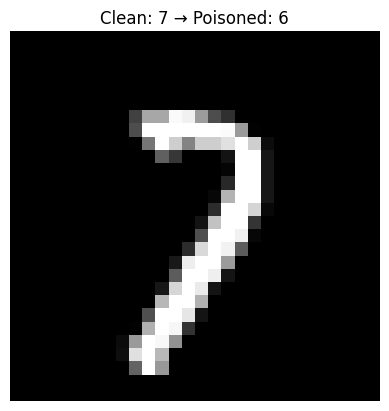

In [ ]:
def visualize_poison(images, clean_labels, poisoned_labels, indices, n=5):
    for i in indices[:n]:
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(f"Clean: {clean_labels[i].item()} → Poisoned: {poisoned_labels[i].item()}")
        plt.axis("off")
visualize_poison(train_images, train_labels, poisoned_labels, poisoned_indices)


Random Label Flipping Examples:
Targeted Label Flipping Examples:
Backdoor Poisoning Examples:


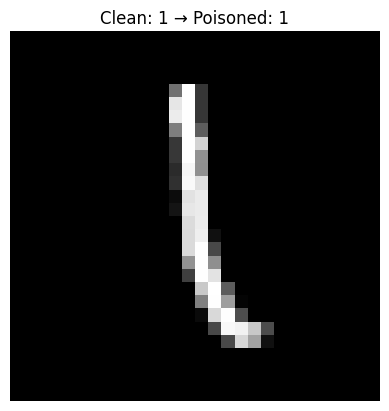

In [ ]:
print("Random Label Flipping Examples:")
visualize_poison(train_images, train_labels, poisoned_labels, poisoned_indices, n=5)

print("Targeted Label Flipping Examples:")
visualize_poison(train_images, train_labels, targeted_labels, targeted_indices, n=5)

print("Backdoor Poisoning Examples:")
visualize_poison(train_images, train_labels, backdoor_labels, backdoor_indices, n=5)

In [ ]:
#### Posioning data out line
####image manipulate Ideas  (This is idea mainly comes down to missing labeling )
 ## ??? What is the end goal of image manipulate ??? Which
  # Axis fliping (Filping the image)
  # Axis rotation (Rotate the image)
  # Blank images (Giving it something to classifiy it that is not in the network.)
  # pixel manipulate (swap the pixel placement of a given pixel with a another pixel [HAVE A SLIDE TO CHANGE 0 TO ALL PIXELS IN THE IMAGE])
####

In [84]:
def image_decolor_manipulate(images,labels, Backgroud_recolor = 0, percent=0.1, num_classes = 10):
  ###############           #################
    M_images = images.clone()
    M_labels = labels.clone()
    num_samples = len(labels)
    num_poison = int(percent * num_samples)
    M_indices = torch.randperm(num_samples)[:num_poison]
###########################################################
    selected = M_images[M_indices]
    selected[selected == 0] = Backgroud_recolor
    M_images[M_indices] = selected
    return M_labels, M_images, M_indices
  ####################################################
import torch.nn.functional as F
def Rescale_image(images, labels,percent_images=0.1, stretch_factor=0.1):
    M_images = images.clone()
    M_labels = labels.clone()
    num_samples = len(images)
    num_modify = int(percent_images * num_samples)
    M_indices = torch.randperm(num_samples)[:num_modify]
    selected = M_images[M_indices]

    ########## Upscale ###############
    new_size = int(28 * stretch_factor)
    stretched = F.interpolate(selected,size=(new_size, new_size),mode='bilinear',align_corners=False)
    ########### Resacle ##################################
    max_offset = new_size - 28
    top = torch.randint(0, max_offset + 1, (1,)).item()
    left = torch.randint(0, max_offset + 1, (1,)).item()
    cropped = stretched[:, :, top:top+28, left:left+28]
    #########################################################
    M_images[M_indices] = cropped

    return M_labels, M_images, M_indices


In [85]:
def Mod_data(images, poisoned_images,clean_labels, poisoned_labels, indices, n=5):
    for i in indices[:n]:
        plt.subplot(1, 2, 2)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(f"Clean: {clean_labels[i].item()}")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

        plt.subplot(1, 2, 2)
        plt.imshow(poisoned_images[i].squeeze(), cmap="gray")
        plt.title(f" Poisoned: {poisoned_labels[i].item()}")
        plt.axis("off")

        plt.tight_layout()
        plt.show()


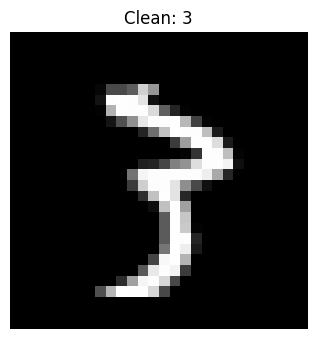

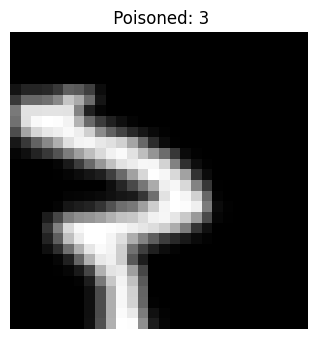

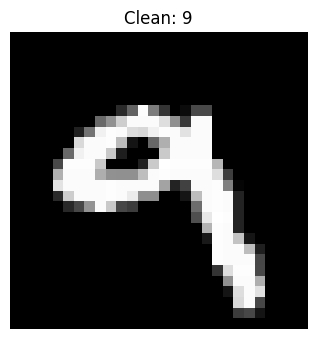

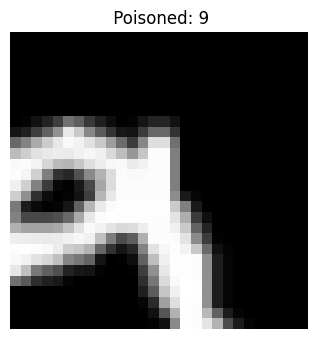

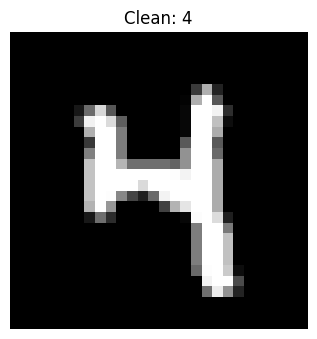

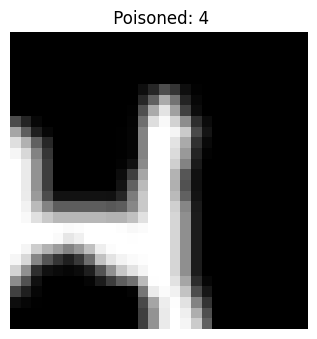

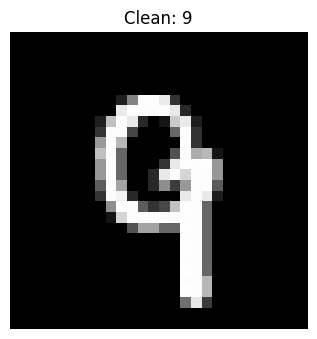

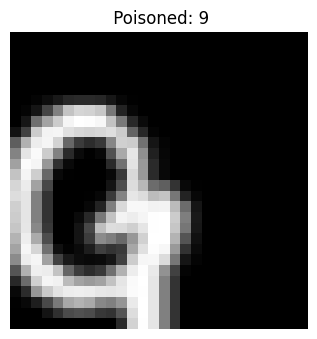

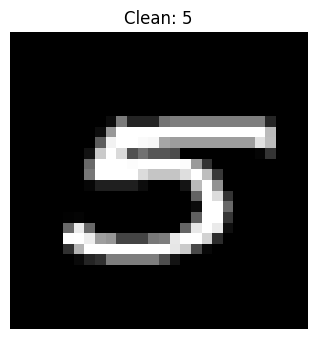

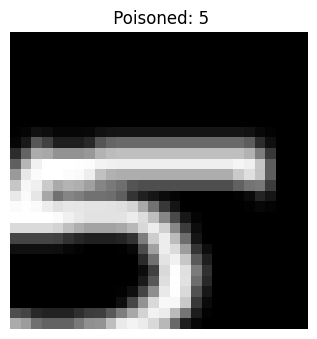

In [ ]:
STRETCHING_FACTOR = 1.5
Filter_labels, Filter_images, Filter_indices = Rescale_image( train_images, train_labels, percent_images=0.1, stretch_factor=STRETCHING_FACTOR)
Mod_data(train_images, Filter_images,train_labels, Filter_labels, Filter_indices)

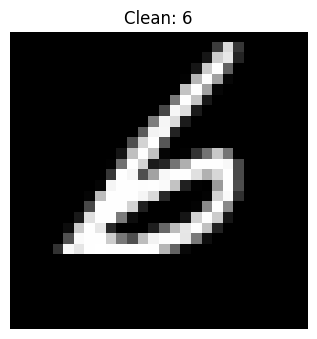

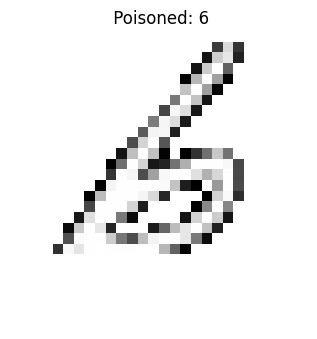

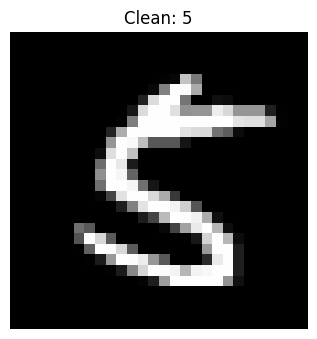

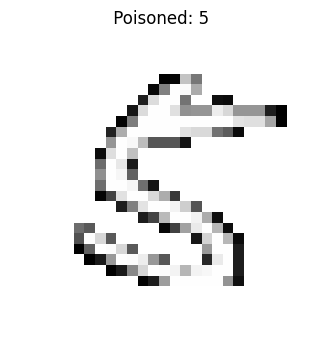

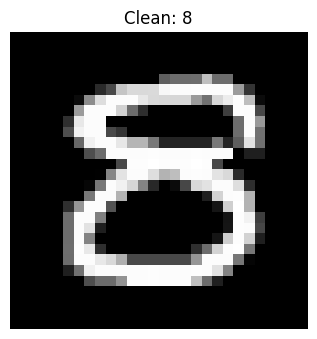

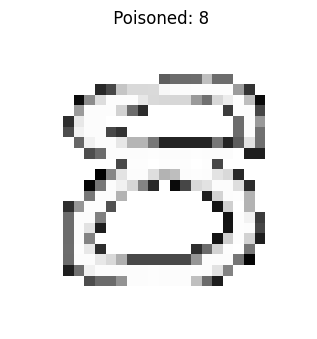

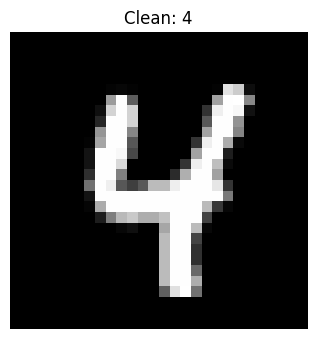

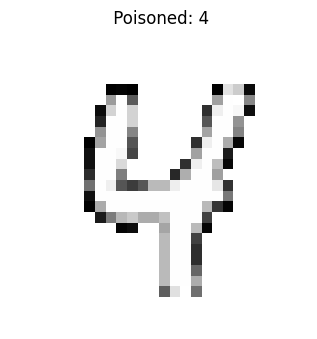

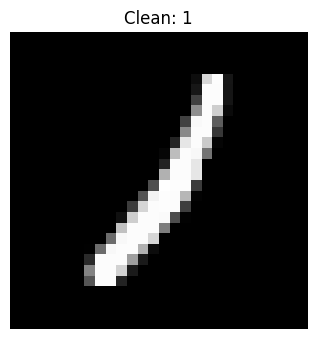

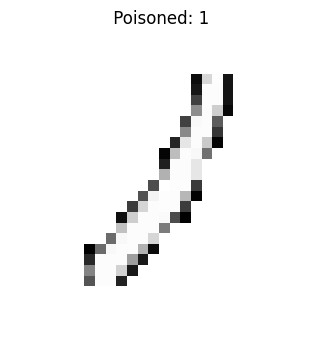

In [ ]:
RECOLOR_FACTOR = 1
Filter_labels, Filter_images, Filter_indices = image_decolor_manipulate(train_images, train_labels, Backgroud_recolor= RECOLOR_FACTOR)
Mod_data(train_images, Filter_images,train_labels, Filter_labels, Filter_indices)



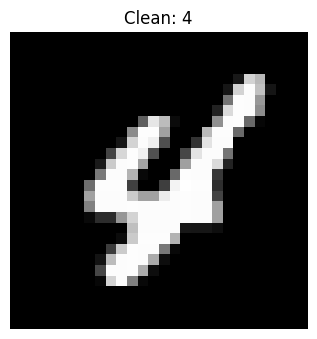

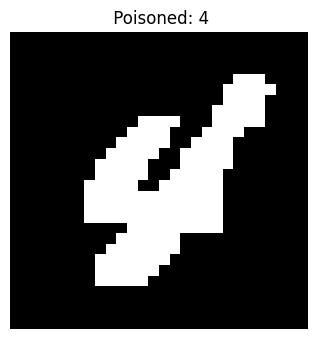

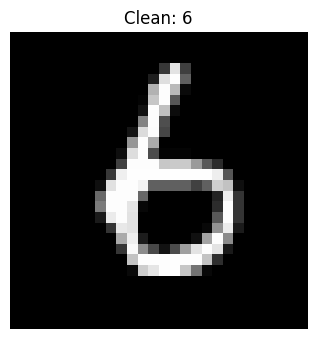

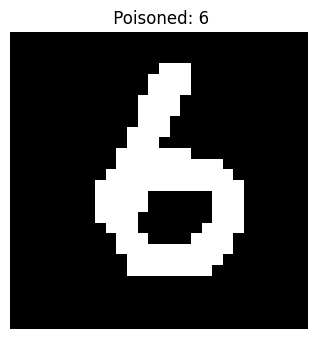

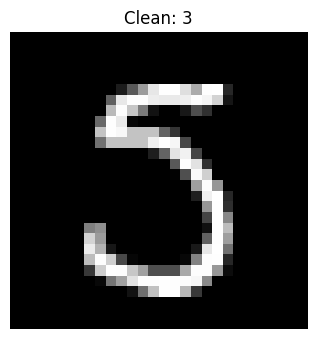

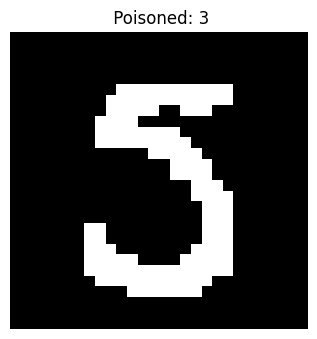

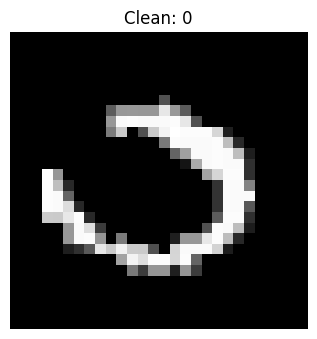

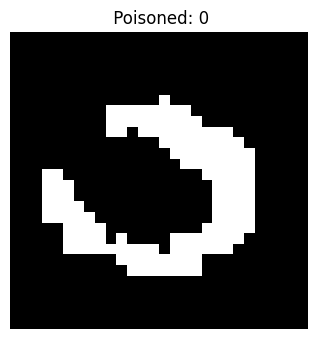

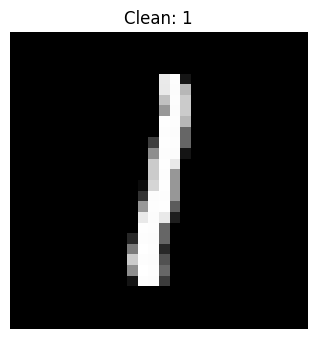

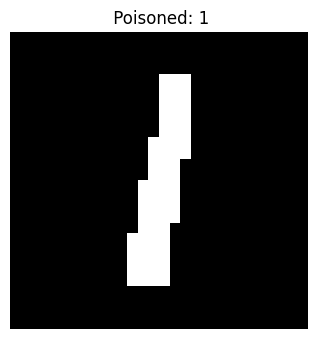

In [89]:
def Void_data(images,labels, recolor = 1, percent=0.1, num_classes = 10):
  ###############           #################
    M_images = images.clone()
    M_labels = labels.clone()
    num_samples = len(labels)
    num_poison = int(percent * num_samples)
    M_indices = torch.randperm(num_samples)[:num_poison]
###########################################################
    selected = M_images[M_indices]
    selected[selected != 0] = recolor
    M_images[M_indices] = selected
    return M_labels, M_images, M_indices
  ####################################################

Filter_labels, Filter_images, Filter_indices = Void_data(train_images, train_labels, recolor= 1)
Mod_data(train_images, Filter_images,train_labels, Filter_labels, Filter_indices)

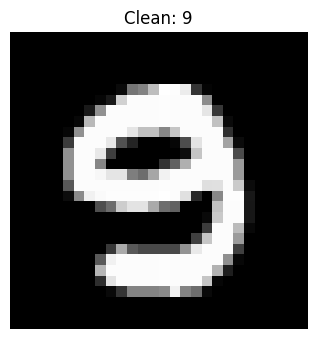

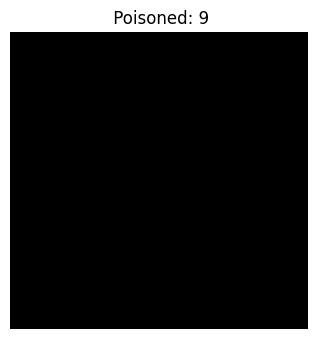

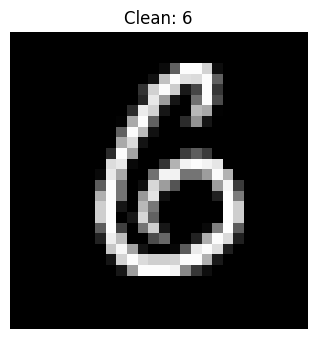

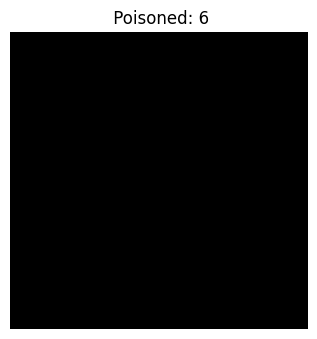

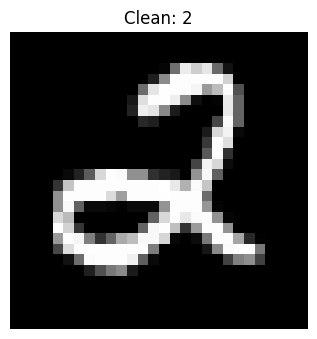

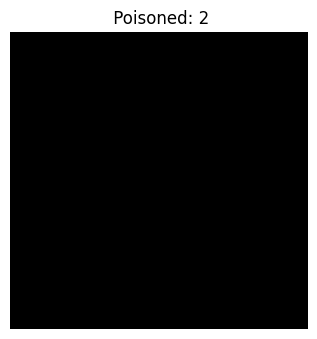

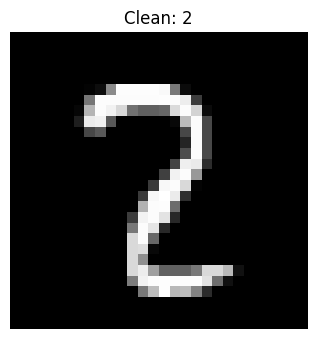

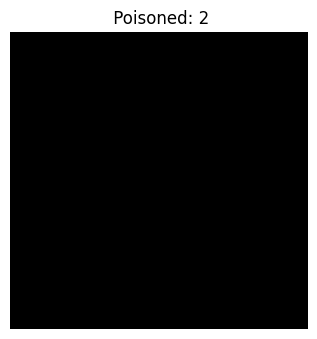

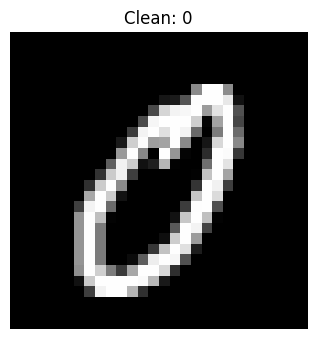

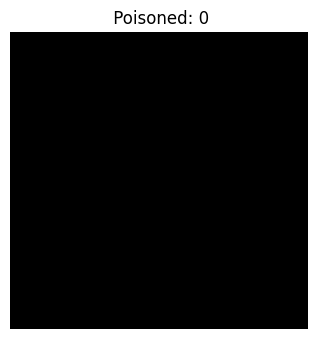

In [90]:
RECOLOR = 0
Filter_labels, Filter_images, Filter_indices = Void_data(train_images, train_labels, recolor= RECOLOR)
Mod_data(train_images, Filter_images,train_labels, Filter_labels, Filter_indices)